# Getting started with Parse endpoint

## Overview

Cohere's Parse is a vision language model that converts unstructured enterprise documents into structured output for AI knowledge applications such as search & retrieval and RAG pipelines.

It extracts text and reading order, tables, lists, forms and key-value pairs, and images with captions. With `output_format="blocks"`, each page returns an ordered list of content blocks — `text`, `image`, and `table` — including bounding boxes and image categories (e.g. `logo`, `signature`, `flowchart`).

Docs: https://docs.cohere.com/v2/docs/parse

**Before running:** make sure you have copied `.env.example` to `.env` at the project root and filled in the `PARSE_*` values (model, endpoint URL, API key).

> Note: the API accepts images as base64 data URIs. Sample images are re-encoded to plain JPEG with Pillow before sending.

In [ ]:
import os, io, json, base64
from dotenv import load_dotenv
from PIL import Image
import cohere
from IPython.display import display, Image as IPyImage
from pygments import highlight
from pygments.lexers import JsonLexer
from pygments.formatters import TerminalFormatter

load_dotenv(override=True)

co = cohere.ClientV2(
    base_url=os.environ["PARSE_BASE_URL"],
    api_key=os.environ["PARSE_API_KEY"],
    timeout=300,
)
MODEL = os.environ["PARSE_MODEL"]

def to_data_uri(path):
    """Re-encode an image as a JPEG base64 data URI (also converts JPEG 2000)."""
    im = Image.open(path).convert("RGB")
    buf = io.BytesIO()
    im.save(buf, "JPEG", quality=90)
    return "data:image/jpeg;base64," + base64.b64encode(buf.getvalue()).decode()

def prune(obj):
    """Recursively drop null fields for a cleaner JSON view."""
    if isinstance(obj, dict):
        return {k: prune(v) for k, v in obj.items() if v is not None}
    if isinstance(obj, list):
        return [prune(v) for v in obj]
    return obj

def parse_file(path):
    """Display the input image, call Parse with blocks output, show indented JSON."""
    display(IPyImage(filename=str(path), width=480))
    response = co.parse(
        model=MODEL,
        document={"type": "image_url", "image_url": to_data_uri(path)},
        output_format="blocks",
    )
    data = prune(response.model_dump())
    for page in data.get("pages", []):
        for block in page.get("blocks", []):
            for value in block.values():
                if isinstance(value, dict) and "html" in value:
                    value["html"] = value["html"][:120] + " ..."
    # 16-color ANSI adapts to light/dark themes; pygments "friendly" hardcodes light-theme colors
    print(highlight(json.dumps(data, indent=2, default=str), JsonLexer(), TerminalFormatter()))

## Input 1: scanned CD document (with signature)

In [ ]:
print("*** This is the first parse endpoint call. If you get errors here, check your .env file for correctness.\n")
parse_file("sample_inputs/cd_scanned_with_signature.jpg")

## Input 2: healthcare cost report

In [ ]:
parse_file("sample_inputs/healthcare_cost_report.jpg")

## Alternative: calling the /parse endpoint directly over HTTP

Under the hood, the `cohere` SDK simply POSTs to the deployment's `/v2/parse` route with your API key. Microsoft's Foundry inference SDK (`azure-ai-inference`) currently only exposes chat-completions and embeddings clients — Parse is invoked via the Cohere SDK or plain HTTP.

This cell shows the raw HTTP version with `requests` — useful for debugging or non-Python clients. (Serverless endpoints on `*.inference.ai.azure.com` use an `api-key: <key>` header instead of `Authorization: Bearer`.)

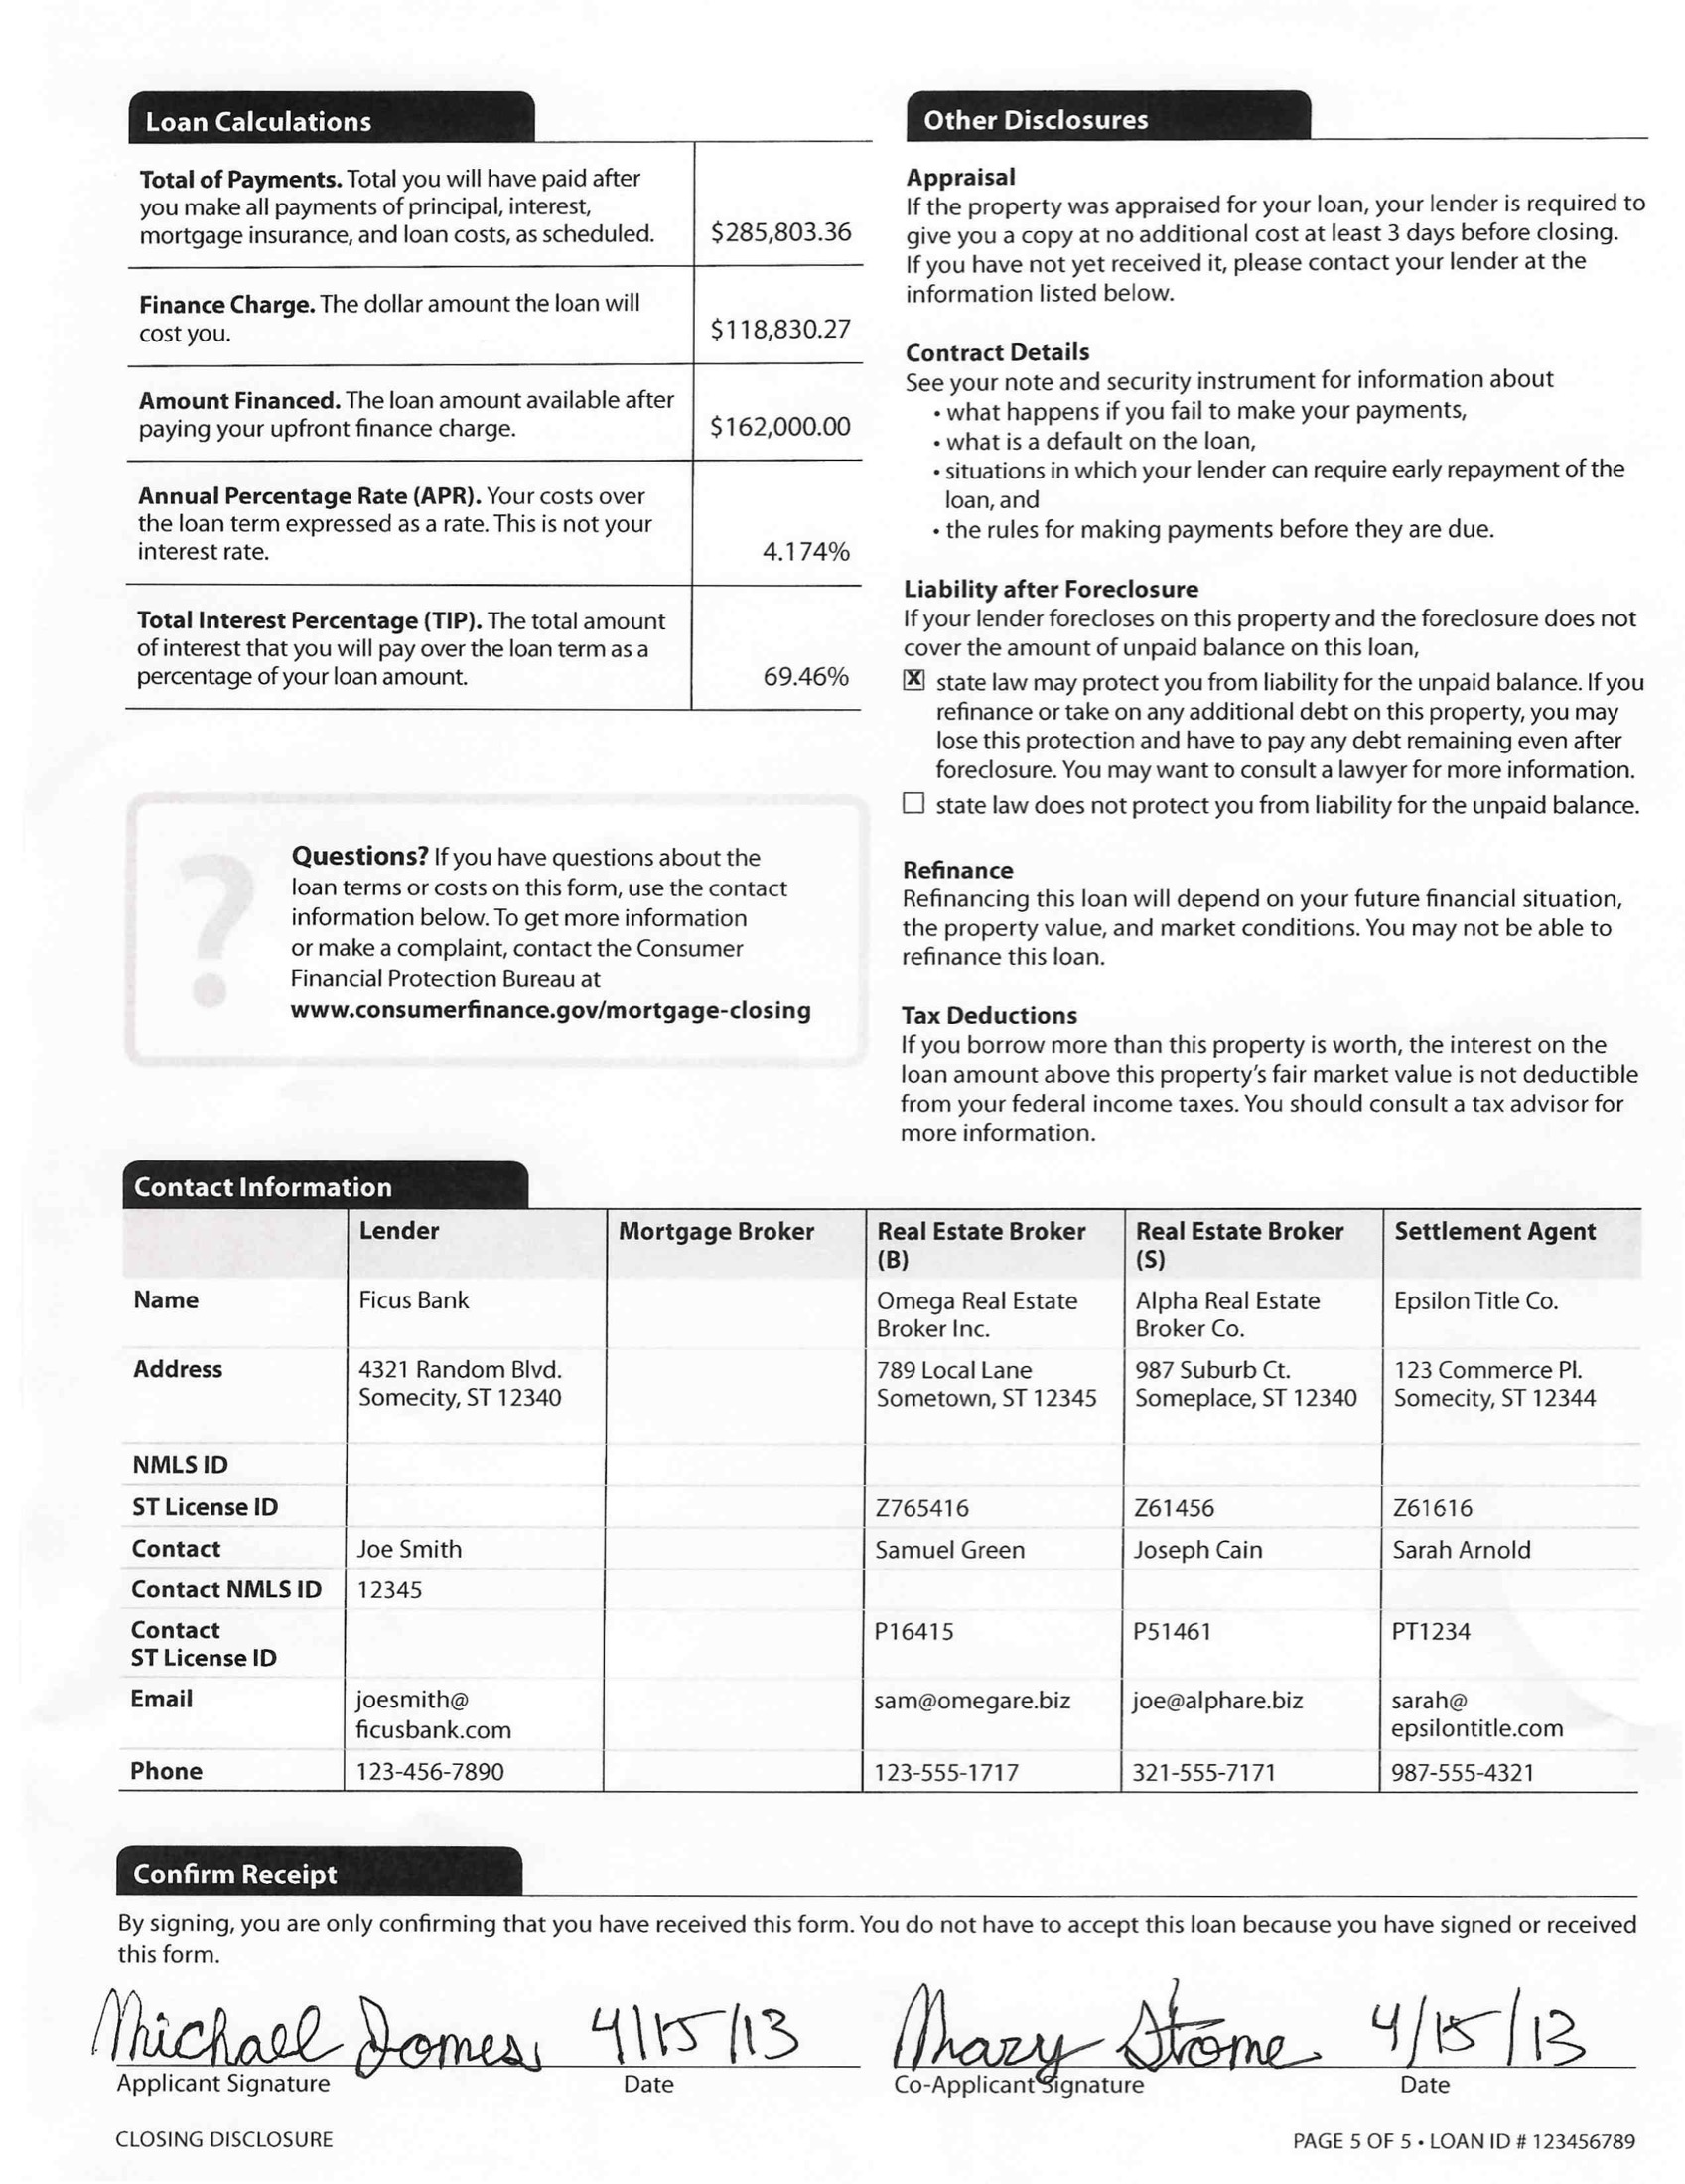

{
  "id": "64bc88e1-a4a2-4bf3-a2d0-24fe2ac13b1e",
  "pages": [
    {
      "index": 0,
      "type": "blocks",
      "blocks": [
        {
          "type": "text",
          "text": {
            "content": "# Loan Calculations"
          }
        },
        {
          "type": "table",
          "table": {
            "type": "html",
            "html": "<table><tr><td>Total of Payments. Total you will have paid after you make all payments of principal, interest, mortgage  ...",
            "description": "The table lists five key loan metrics. Total Payments are $285,803.36. Finance Charge is $118,830.27. Amount Financed is $162,000.00. Annual Percentage Rate (APR) is 4.174%. Total Interest Percentage (TIP) is 69.46%.",
            "bounding_box": {
              "top_left_x": 127,
              "top_left_y": 99,
              "bottom_right_x": 869,
              "bottom_right_y": 733
            },
            "bounding_box_normalized": {
              "top_left_x": 0.075,
       

In [2]:
import os, io, json, base64, requests
from PIL import Image
from IPython.display import display, Image as IPyImage
from pygments import highlight
from pygments.lexers import JsonLexer
from pygments.formatters import TerminalFormatter

def prune(obj):
    """Recursively drop null fields for a cleaner JSON view."""
    if isinstance(obj, dict):
        return {k: prune(v) for k, v in obj.items() if v is not None}
    if isinstance(obj, list):
        return [prune(v) for v in obj]
    return obj

def parse_file_http(path):
    """Parse an image via a raw POST to the /parse route — no SDK needed."""
    url = os.environ["PARSE_BASE_URL"].rstrip("/") + "/v2/parse"
    im = Image.open(path).convert("RGB")
    buf = io.BytesIO()
    im.save(buf, "JPEG", quality=90)
    image_b64 = base64.b64encode(buf.getvalue()).decode()
    display(IPyImage(filename=str(path), width=480))
    response = requests.post(
        url,
        headers={"api-key": os.environ["PARSE_API_KEY"]},
        json={
            "model": os.environ["PARSE_MODEL"],
            "document": {"type": "image_url", "image_url": f"data:image/jpeg;base64,{image_b64}"},
            "output_format": "blocks",
        },
        timeout=300,
    )
    response.raise_for_status()
    data = prune(response.json())
    for page in data.get("pages", []):
        for block in page.get("blocks", []):
            for value in block.values():
                if isinstance(value, dict) and "html" in value:
                    value["html"] = value["html"][:120] + " ..."
    print(highlight(json.dumps(data, indent=2), JsonLexer(), TerminalFormatter()))

parse_file_http("sample_inputs/cd_scanned_with_signature.jpg")

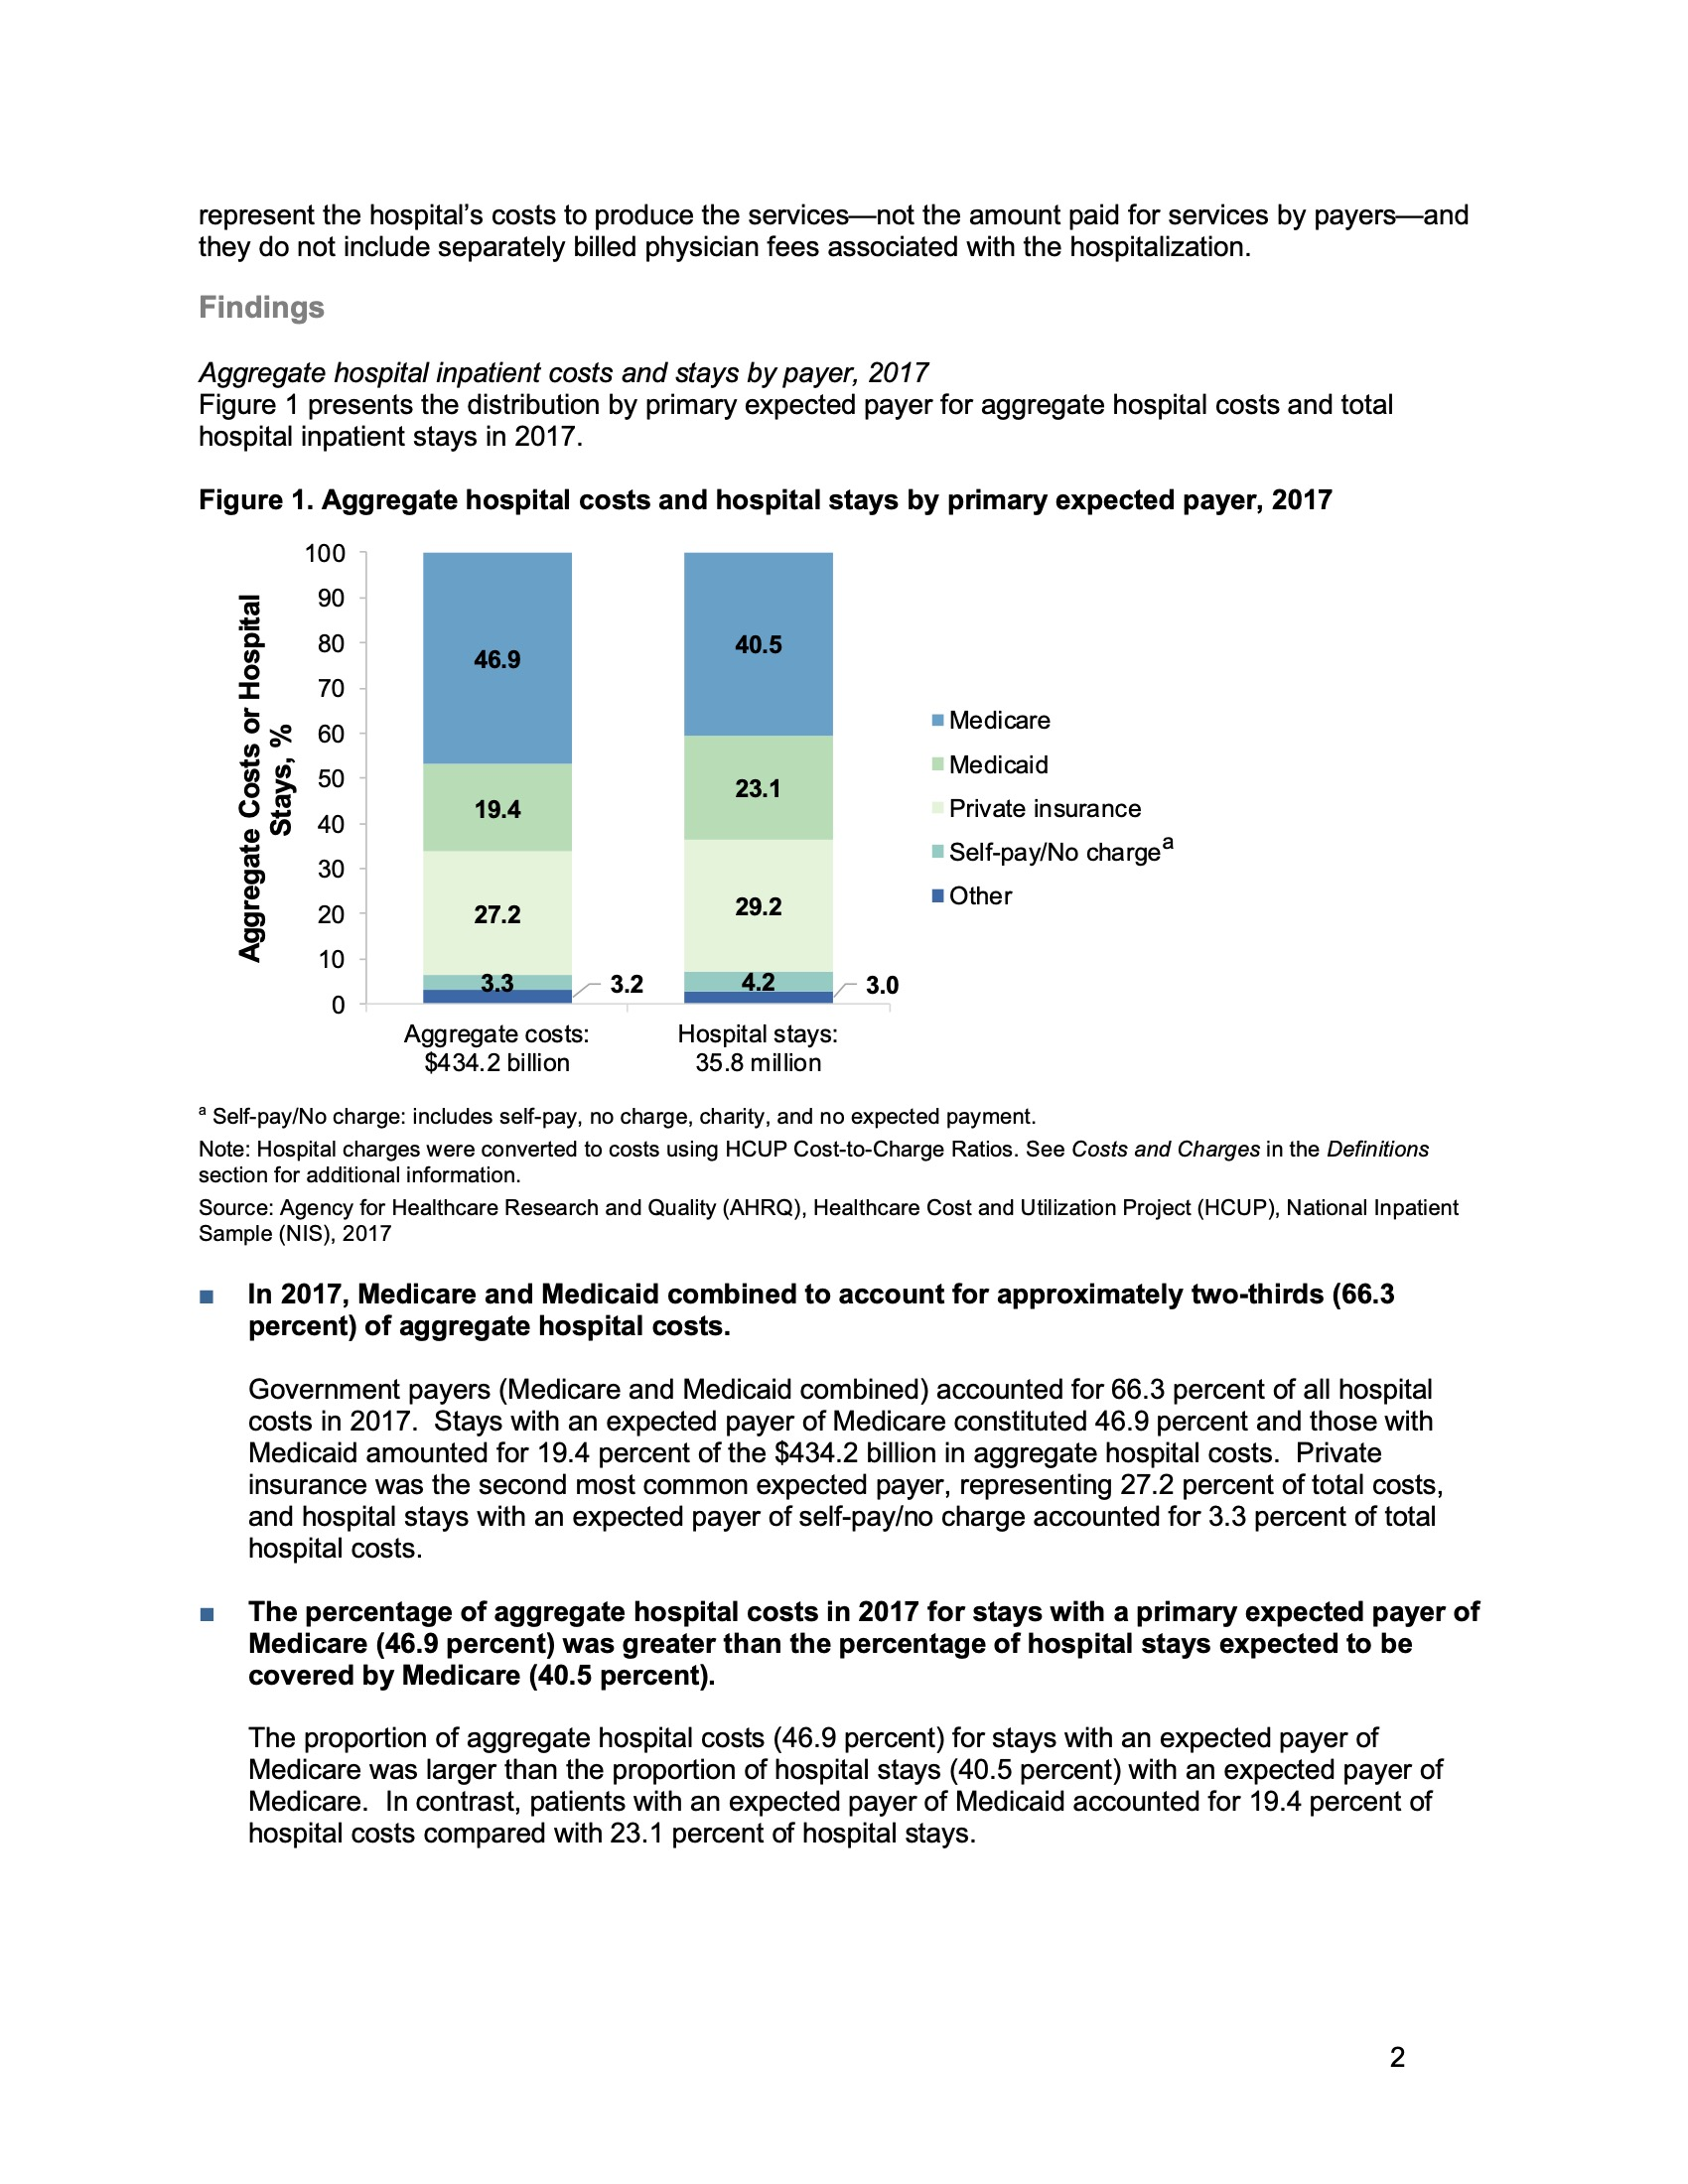

{
  "id": "5e679a9a-6574-4976-bfd9-19c5a12c666e",
  "pages": [
    {
      "index": 0,
      "type": "blocks",
      "blocks": [
        {
          "type": "text",
          "text": {
            "content": "represent the hospital's costs to produce the services\u2014not the amount paid for services by payers\u2014and they do not include separately billed physician fees associated with the hospitalization.\n\n## Findings\n\n*Aggregate hospital inpatient costs and stays by payer, 2017*\n\nFigure 1 presents the distribution by primary expected payer for aggregate hospital costs and total hospital inpatient stays in 2017.\n\n**Figure 1. Aggregate hospital costs and hospital stays by primary expected payer, 2017**"
          }
        },
        {
          "type": "image",
          "image": {
            "id": "img-0",
            "description": "The chart displays two stacked bars representing \"Aggregate Costs or Hospital Stays, %\" on the y-axis (0-100). The left bar represents \"Agg

In [3]:
parse_file_http("sample_inputs/healthcare_cost_report.jpg")